In [1]:
# pytorch

In [2]:
import numpy as np

# xor problem
# 0 0 -> 0
# 0 1 -> 1
# 1 0 -> 1
# 1 1 -> 0

X = np.array([[0, 0], [0, 1], [1, 0], [1, 1]])
y = np.array([[0], [1], [1], [0]])

input_layer_size = 2
hidden_layer_size = 3
output_layer_size = 1

In [3]:
weights_input_hidden = np.random.uniform(-1, 1, (input_layer_size, hidden_layer_size))
bias_input_hidden = np.random.uniform(-1, 1, hidden_layer_size)


weights_input_hidden, bias_input_hidden

(array([[ 0.02164031,  0.58583889,  0.68440666],
        [ 0.48584819, -0.94772577,  0.64014995]]),
 array([ 0.75567664, -0.16285124,  0.45193712]))

In [4]:
weights_hidden_output = np.random.uniform(-1, 1, (hidden_layer_size, output_layer_size))
bias_hidden_output = np.random.uniform(-1, 1, output_layer_size)

weights_hidden_output, bias_hidden_output

(array([[ 0.49000977],
        [-0.33631367],
        [-0.69767321]]),
 array([-0.73300904]))

In [5]:
epochs = 10000
learning_rate = 0.1

In [6]:
for epoch in range(epochs):
    # forward pass
    hidden_layer_input = np.dot(X, weights_input_hidden) + bias_input_hidden
    hidden_layer_output = 1 / (1 + np.exp(-hidden_layer_input))  # sigmoid activation

    output_layer_input = (
        np.dot(hidden_layer_output, weights_hidden_output) + bias_hidden_output
    )
    predicted_output = 1 / (1 + np.exp(-output_layer_input))  # sigmoid activation

    # calculate error
    error = predicted_output - y

    # backpropagation
    d_predicted_output = error * (
        predicted_output * (1 - predicted_output)
    )  # derivative of sigmoid
    error_hidden_layer = d_predicted_output.dot(weights_hidden_output.T)
    d_hidden_layer = error_hidden_layer * (
        hidden_layer_output * (1 - hidden_layer_output)
    )  # derivative of sigmoid

    # update weights and biases
    weights_hidden_output -= (
        hidden_layer_output.T.dot(d_predicted_output) * learning_rate
    )
    bias_hidden_output -= np.sum(d_predicted_output, axis=0) * learning_rate
    weights_input_hidden -= X.T.dot(d_hidden_layer) * learning_rate
    bias_input_hidden -= np.sum(d_hidden_layer, axis=0) * learning_rate

In [7]:
# prediction after training
hidden_layer_input = np.dot(X, weights_input_hidden) + bias_input_hidden
hidden_layer_output = 1 / (1 + np.exp(-hidden_layer_input))  # sigmoid activation

output_layer_input = (
    np.dot(hidden_layer_output, weights_hidden_output) + bias_hidden_output
)
predicted_output = 1 / (1 + np.exp(-output_layer_input))  # sigmoid activation

print("Predicted output after training:")
print(predicted_output)

Predicted output after training:
[[0.05640633]
 [0.92970579]
 [0.94480056]
 [0.07584173]]


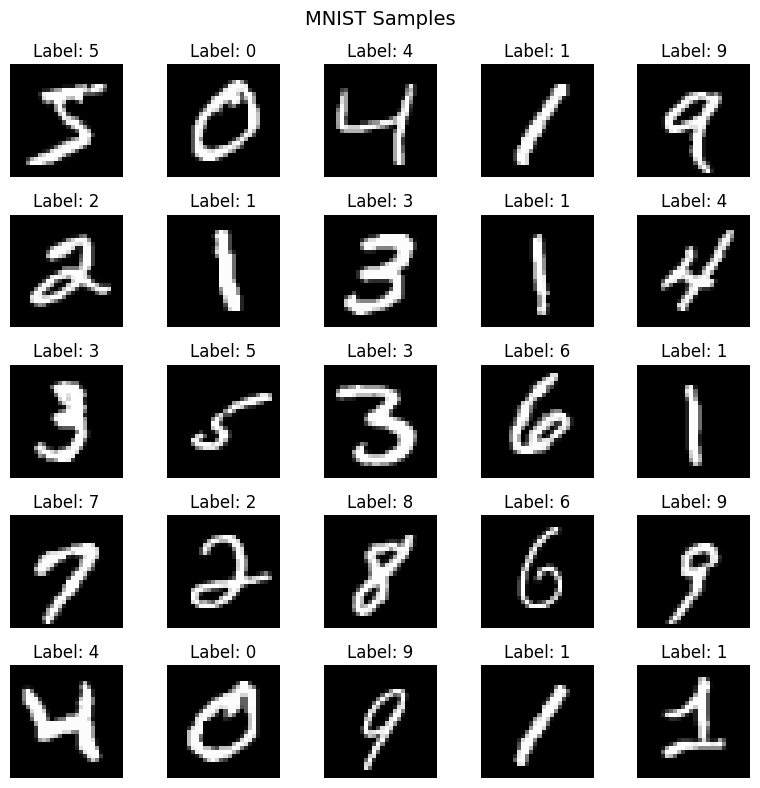

In [ ]:
import torch
from torchvision import datasets, transforms
import matplotlib.pyplot as plt

# Download MNIST dataset
transform = transforms.ToTensor()
train_mnist = datasets.MNIST(
    root="./data", train=True, download=True, transform=transform
)
test_mnist = datasets.MNIST(
    root="./data", train=False, download=True, transform=transform
)


# Show a grid of 25 sample images
fig, axes = plt.subplots(5, 5, figsize=(8, 8))
for i, ax in enumerate(axes.flat):
    img, label = train_mnist[i]
    ax.imshow(img.squeeze(), cmap="gray")
    ax.set_title(f"Label: {label}")
    ax.axis("off")

plt.suptitle("MNIST Samples", fontsize=14)
plt.tight_layout()
plt.show()


In [9]:
batch_size = 64

train_loader = torch.utils.data.DataLoader(
    train_mnist, batch_size=batch_size, shuffle=True
)
test_loader = torch.utils.data.DataLoader(
    test_mnist, batch_size=batch_size, shuffle=False
)

In [ ]:
class FFNN(torch.nn.Module):
    def __init__(self):
        super(FFNN, self).__init__()
        self.fc1 = torch.nn.Linear(28 * 28, 12)  # fully connected layer 1
        self.fc2 = torch.nn.Linear(12, 4)
        self.fc3 = torch.nn.Linear(4, 10)

    # 784 -> 128 -> 64 -> 10
    # input -> hidden1 -> hidden2 -> output

    def forward(self, x):
        l1_input = self.fc1(x.view(-1, 28 * 28))
        l1_output = torch.relu(l1_input)
        l2_input = self.fc2(l1_output)
        l2_output = torch.relu(l2_input)
        logits = self.fc3(l2_output)
        output = torch.softmax(logits, dim=1)
        return output

In [11]:
# activation function
# relu(x) = max(0, x)

In [12]:
logits = [1.2, 0.3, -0.5, 0.8, 0.1, 0.4, -0.2, 0.6, 0.9, -0.1]
# softmax manually
exp_logits = np.exp(logits)
softmax_manual = exp_logits / np.sum(exp_logits)
softmax_manual

array([0.20616296, 0.0838196 , 0.03766258, 0.13819516, 0.06862569,
       0.09263499, 0.05083916, 0.11314463, 0.15272928, 0.05618596])

In [13]:
# softmax
#                        0,   1,    2,   3,   4,   5,   6,   7,   8,   9
logits = torch.tensor([1.2, 0.3, -0.5, 0.8, 0.1, 0.4, -0.2, 0.6, 0.9, -0.1])
softmax = torch.softmax(logits, dim=0)
softmax

tensor([0.2062, 0.0838, 0.0377, 0.1382, 0.0686, 0.0926, 0.0508, 0.1131, 0.1527,
        0.0562])

In [14]:
# cross entropy loss - manual calculation
sample_pred = softmax.numpy()
sample_y = 7

sample_y_tensor = np.zeros(10)
sample_y_tensor[sample_y] = 1

cross_entropy_loss_manual = -np.sum(sample_y_tensor * np.log(sample_pred))
cross_entropy_loss_manual

np.float64(2.1790883541107178)

In [15]:
epochs = 3
learning_rate = 0.001

In [ ]:
model = FFNN(inptut_size=28 * 28, hidden1_size=12, hidden2_size=4, output_size=10)

criterion = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

In [ ]:
for epoch in range(epochs):
    for b_idx, (images, labels) in enumerate(train_loader):
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        if (b_idx + 1) % 100 == 0:
            print(
                f"Epoch [{epoch + 1}/{epochs}], Step [{b_idx + 1}/{len(train_loader)}], Loss: {loss.item():.4f}"
            )


Epoch [1/3], Step [1/938], Loss: 1.7318
Epoch [1/3], Step [2/938], Loss: 1.7225
Epoch [1/3], Step [3/938], Loss: 1.6768
Epoch [1/3], Step [4/938], Loss: 1.6498
Epoch [1/3], Step [5/938], Loss: 1.6949
Epoch [1/3], Step [6/938], Loss: 1.6730
Epoch [1/3], Step [7/938], Loss: 1.7126
Epoch [1/3], Step [8/938], Loss: 1.8017
Epoch [1/3], Step [9/938], Loss: 1.7134
Epoch [1/3], Step [10/938], Loss: 1.6999
Epoch [1/3], Step [11/938], Loss: 1.6583
Epoch [1/3], Step [12/938], Loss: 1.6986
Epoch [1/3], Step [13/938], Loss: 1.6270
Epoch [1/3], Step [14/938], Loss: 1.7273
Epoch [1/3], Step [15/938], Loss: 1.7017
Epoch [1/3], Step [16/938], Loss: 1.7258
Epoch [1/3], Step [17/938], Loss: 1.6522
Epoch [1/3], Step [18/938], Loss: 1.7502
Epoch [1/3], Step [19/938], Loss: 1.6480
Epoch [1/3], Step [20/938], Loss: 1.6232
Epoch [1/3], Step [21/938], Loss: 1.6725
Epoch [1/3], Step [22/938], Loss: 1.6822
Epoch [1/3], Step [23/938], Loss: 1.6152
Epoch [1/3], Step [24/938], Loss: 1.6702
Epoch [1/3], Step [25/938

In [18]:
# test inference
model.eval()

with torch.no_grad():
    correct = 0
    total = 0
    for images, labels in test_loader:
        outputs = model(images)
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    print(f"Test Accuracy: {100 * correct / total:.2f}%")

Test Accuracy: 78.58%


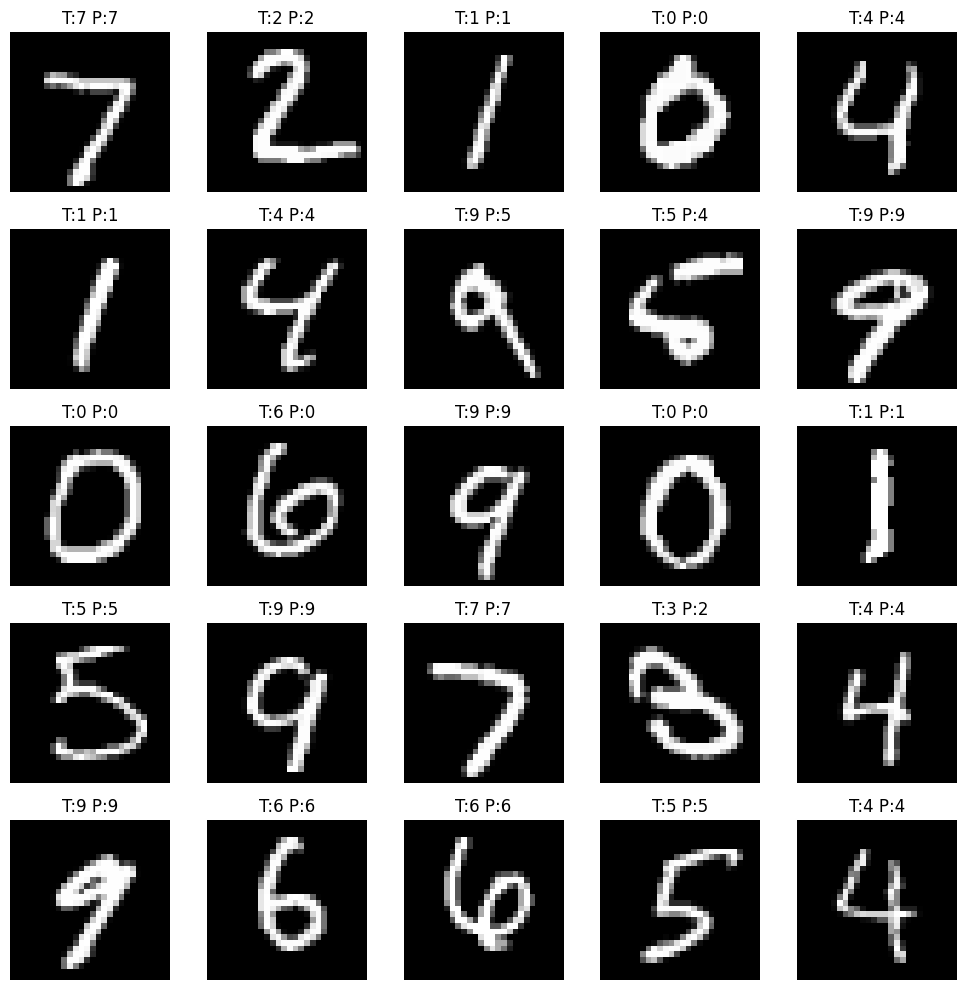

In [19]:
# matplotlib samples from test with predictions
model.eval()
fig, axes = plt.subplots(5, 5, figsize=(10, 10))

with torch.no_grad():
    for i, ax in enumerate(axes.flat):
        img, label = test_mnist[i]
        output = model(img.unsqueeze(0))
        pred = torch.argmax(output, dim=1).item()

        ax.imshow(img.squeeze(), cmap="gray")
        ax.set_title(f"T:{label} P:{pred}")
        ax.axis("off")

plt.tight_layout()
plt.show()